In [ ]:
import os
from collections import Counter
import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ['PYGAME_HIDE_SUPPORT_PROMPT'] = '1'
from eval_genome import test_genome_mp

/home/mabayneh/mabay/asrc/farptest/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def test_genome_against_n(genome: tuple[float, float, float, float], rng_seed=20, samples=10, n_range=[]):
    results: list[dict] = []
    for n in n_range:
        stats, cap_rate = test_genome_mp(genome, n, rng_seed=rng_seed, trials=samples)
        print('n: ', n, sum(stats, Counter()))
        
        for stat in stats:
            results.append({
                "n": n,
                **stat
            })

    return results

In [ ]:
n_range = [
    *range(6, 10),
    # *range(10, 30, 2),
    # *range(30, 100+1, 5),
]

results = test_genome_against_n(
    (0.2, 0.2, 0.2, -0.2),
    n_range=n_range
)

100%|██████████| 10/10 [00:00<00:00, 14.49it/s]


n:  6 Counter({'Time to Detect sub': 1133, 'Time to Capture': 10, 'How many red on goal': 10})


100%|██████████| 10/10 [00:01<00:00,  9.50it/s]


n:  7 Counter({'Time to Detect sub': 1133, 'Time to Capture': 10, 'How many red on goal': 10})


100%|██████████| 10/10 [00:00<00:00, 11.40it/s]

n:  8 Counter({'Time to Detect sub': 1133, 'Time to Capture': 10, 'How many red on goal': 10})



100%|██████████| 10/10 [00:00<00:00, 11.03it/s]

n:  9 Counter({'Time to Detect sub': 1127, 'Time to Capture sub': 217, 'Time to Capture': 9, 'How many red on goal': 9})


In [ ]:
results

In [ ]:
df = pd.DataFrame.from_dict(results)

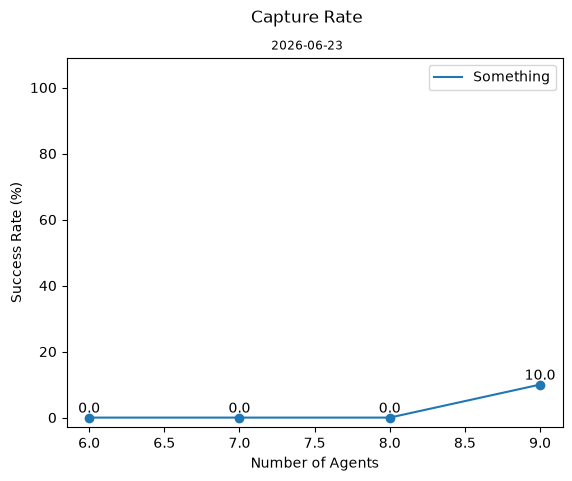

In [ ]:
def srate(df, name='Success'):
    x = (100 - df.groupby(['n'])['How many red on goal'].mean() * 100).round().rename(f'{name} Rate')
    return x.index, x

plt.plot(*srate(df), label='Something')
plt.legend()
plt.scatter(*srate(df))

dt_title = dt.datetime.now().strftime("%Y-%m-%d")
plt.title(dt_title, size='small', x=0.485)
plt.suptitle('Capture Rate')
plt.xlabel('Number of Agents')
plt.ylabel('Success Rate (%)')
margin = 3
plt.ylim(0 - margin, 100 + 3*margin)

for n, sr in zip(*srate(df)):
    plt.text(n, sr + 0.5, str(sr), ha="center", va="bottom")
